In [1]:
import os

if 'OPENAI_API_KEY' in os.environ:
    del os.environ['OPENAI_API_KEY']

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
#PINECONE_API_KEY = os.environ['PINECONE_API_KEY']

print("API 키 로드 완료")
print(f"OpenAI Key: {OPENAI_API_KEY[:10]}...")

API 키 로드 완료
OpenAI Key: sk-proj-00...


In [3]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt > LLM(ChatOpenAI) > output_parsers

In [14]:
text = "{topic}에 대해 한 문장으로 설명해줘"

In [15]:
llm = ChatOpenAI(model="gpt-4o-mini")
prompt = PromptTemplate.from_template(text)
output_parser = StrOutputParser()

In [16]:
chain = prompt | llm | output_parser

In [26]:
chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='{topic}에 대해 한 문장으로 설명해줘')
| ChatOpenAI(profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000224338DC140>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000224339F6EA0>, root_client=<openai.OpenAI object at 0x00000224321AB7A0>, root_async_clie

In [27]:
result = chain.invoke({"topic": "랭체인"})
result

'랭체인(RLangChain)은 자연어 처리(NLP) 모델을 활용하여 다양한 데이터 소스와 연결하고, 이를 통해 복잡한 작업을 자동화하는 프레임워크입니다.'

In [28]:
message = [("system", "당신은 서울의 음식과 문화 전문가입니다."), ("human", "서울을 대표하는 음식을 맛볼 수 있는 레스토랑 5개를 추천해 주세요.")]

In [30]:
res = llm.invoke(message)
res

AIMessage(content='서울에서 전통 음식을 맛볼 수 있는 추천 레스토랑 5곳입니다:\n\n1. **광화문 미진**  \n   - **특징:** 전통 한정식 전문점으로, 여러 가지 제철 재료를 사용한 다양한 반찬과 함께 잘 숙성된 고기를 제공. 고급스러운 분위기에서 한식을 경험할 수 있습니다.\n\n2. **을지로 순대국**  \n   - **특징:** 서울의 유명한 순대국밥 집으로, 깊은 국물 맛과 신선한 순대가 일품입니다. 맛과 푸짐함으로 많은 지역 주민들에게 사랑받고 있습니다.\n\n3. **김치찌개 이태원**  \n   - **특징:** 정통 김치찌개를 전문으로 하는 이곳은 진한 국물과 풍부한 재료가 특징입니다. 깔끔한 인테리어와 친절한 서비스로 편안한 식사를 즐길 수 있습니다.\n\n4. **대도식당**  \n   - **특징:** 서울의 자랑인 갈비탕과 육개장으로 유명한 식당입니다. 푸짐한 한 그릇에 신선한 육수를 자랑하며, 정통 한식을 원하는 이들에게 제격입니다.\n\n5. **종로할매국수**  \n   - **특징:** 서울 전통 국수의 맛을 느낄 수 있는 곳으로, 담백하고 깔끔한 국물과 쫄깃한 면발이 조화를 이루는 음식입니다. 빠르고 간편하게 한 끼를 해결할 수 있습니다.\n\n서울의 다양한 전통 음식을 즐기기에 이 레스토랑들이 좋은 선택이 될 것입니다. 맛있는 경험하세요!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 372, 'prompt_tokens': 43, 'total_tokens': 415, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_toke

In [ ]:
#agent

In [9]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain.agents import create_agent   # LangChain 1.x
from langgraph.prebuilt import create_react_agent

In [27]:
@tool
def add(a:float, b:float) -> float: 
  """두 숫자를 더합니다"""
  return a+b

In [28]:
@tool
def multiply(a:float, b:float) -> float: 
  """두 숫자를 곱합니다."""
  return a*b

In [29]:
tools = [add, multiply]

C:\Users\Admin\AppData\Local\Temp\ipykernel_5288\2125601103.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


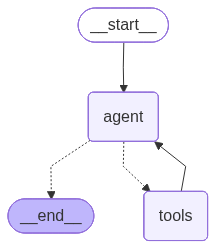

In [30]:
agent = create_react_agent(
  prompt = "당신은 계산을 도와주는 어시스턴트입니다.",
  model= llm,
  tools = tools
)
agent

In [31]:
result = agent.invoke({
  "messages": [{"role": "user",
                "content": "3 더하기 5는 얼마입니까? 그리고 그 결과에 7을 곱하면?"}]
})

In [32]:
for msg in result["messages"]:
  print(f"[{msg.__class__.__name__}] {msg.content[:80] if msg.content else '(tool call)'}")

[HumanMessage] 3 더하기 5는 얼마입니까? 그리고 그 결과에 7을 곱하면?
[AIMessage] (tool call)
[ToolMessage] 8.0
[ToolMessage] 56.0
[AIMessage] 3 더하기 5는 8입니다. 그 결과에 7을 곱하면 56이 됩니다.


In [ ]:
#웹검색 에이전트 도구 실습

In [21]:
from dotenv import load_dotenv
load_dotenv()

from langchain_tavily import TavilySearch

In [22]:
search_tool = TavilySearch(max_results=3)

In [23]:
import ast
import operator

# 1. 도구 정의: 웹 검색
search_tool = TavilySearch(max_results=3)

# 2. 도구 정의: 안전한 계산기
SAFE_OPERATORS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
}

def _safe_eval(node):
    if isinstance(node, ast.Constant):
        return node.value
    elif isinstance(node, ast.BinOp):
        op = SAFE_OPERATORS.get(type(node.op))
        if op is None:
            raise ValueError(f"지원하지 않는 연산자: {node.op}")
        return op(_safe_eval(node.left), _safe_eval(node.right))
    raise ValueError(f"허용되지 않는 표현식: {node}")

In [ ]:
# safe calc 도구

In [24]:
@tool
def calculate(expression: str) -> str:
    """사칙연산과 거듭제곱만 허용하는 안전한 계산기입니다. 예: '1234 * 5678'"""
    try:
        tree = ast.parse(expression, mode="eval")
        result = _safe_eval(tree.body)
        return str(result)
    except Exception as e:
        return f"계산 오류: {e}"

In [ ]:
# 에이전트 생성

In [39]:
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [47]:
agent = create_react_agent(
    model=llm,
    tools=[search_tool, calculate],
    prompt="""당신은 웹 검색과 계산을 도와주는 AI 어시스턴트입니다.

규칙:
- 동일하거나 유사한 검색 쿼리를 반복하지 마세요.
- 검색 결과가 없으면 즉시 그 사실을 사용자에게 알리세요.
- 최대 3번 검색 후 반드시 최종 답변을 제공하세요.""",
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5288\105298318.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


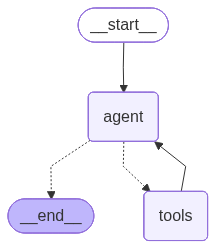

In [41]:
agent

In [48]:
result = agent.invoke({
  "messages": [{"role": "user",
                "content":"2024년 한국 GDP를 검색하고, 그 금액을 1300으로 나누면 얼마야?"}]
})
result

{'messages': [HumanMessage(content='2024년 한국 GDP를 검색하고, 그 금액을 1300으로 나누면 얼마야?', additional_kwargs={}, response_metadata={}, id='2ad52f65-703a-4cc5-9acb-096f20686d95'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1324, 'total_tokens': 1344, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0a066d21a2', 'id': 'chatcmpl-DRvFWUMBcjWYGqFkWdCxUYT40xENA', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d66dd-9b09-7fb2-a2fd-6975c2d2ef61-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '2024 South Korea GDP'}, 'id': 'call_Op7Fs61UdvwUCZPFlvhOrvaJ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_met

In [49]:
for msg in result["messages"]:
  print(f"[{msg.__class__.__name__}] {msg.content[:80] if msg.content else '(tool call)'}")

[HumanMessage] 2024년 한국 GDP를 검색하고, 그 금액을 1300으로 나누면 얼마야?
[AIMessage] (tool call)
[ToolMessage] {"query": "2024 South Korea GDP", "response_time": 1.76, "follow_up_questions": 
[AIMessage] (tool call)
[ToolMessage] {"query": "South Korea GDP 2024 amount", "response_time": 0.53, "follow_up_quest
[AIMessage] (tool call)
[ToolMessage] 1461538461.5384614
[AIMessage] 2024년 한국의 GDP는 약 1.9조 달러(1,900,000,000,000 USD)입니다. 이 금액을 1300으로 나누면 약 1,461,538
